In [69]:
# Libraries

import pandas as pd

In [70]:
# Uploading file
df = pd.read_csv('all_tickets_processed_improved_v3.csv')
df.head()

# Understanding data
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 747.6 KB


,Document,Topic_group
count,47837,47837
unique,47837,8
top,connection with icon icon dear please setup ic...,Hardware
freq,1,13617


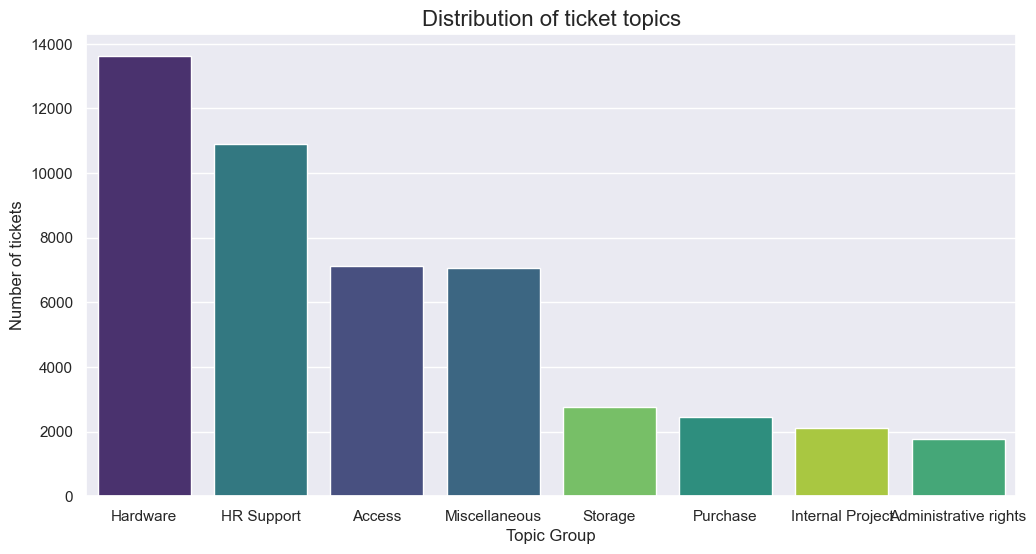

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count Plot to see how ticket volume is distributed

sns.set_theme(style="darkgrid") # visual style
plt.figure(figsize=(12,6))      # figure size

visual = sns.countplot(data=df,x='Topic_group', hue='Topic_group',order=df['Topic_group'].value_counts().index,palette='viridis',legend=False) # create count plot, order value_counts to make imbalance easier to see
plt.title('Distribution of ticket topics', fontsize=16)
plt.xlabel('Topic Group', fontsize=12)
plt.ylabel('Number of tickets', fontsize=12)

plt.show()

In [72]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [73]:

# Filtering words out of ticket description (stopwords)
# Getting dictionary 
import string

stop_words = set(stopwords.words('english')) # loading English words

# Cleaning: Lowercase text, remove punctuation, and take out stopwords
def cleanText(text):
    text = text.lower()
    text = "".join([char for char in text if char not in string.punctuation])
    words = nltk.word_tokenize(text) # split into words
    final_words = [s for s in words if s not in stop_words]

    return " ".join(final_words)

df['Document'] = df['Document'].astype(str).apply(cleanText) # cleaned text in Document

print(df['Document'].head())


0    connection icon icon dear please setup icon pe...
1    work experience user work experience user hi w...
2    requesting meeting requesting meeting hi pleas...
3    reset passwords external accounts expire days ...
4    mail verification warning hi got attached plea...
Name: Document, dtype: str


In [74]:
# Turning text into numbers, Vectorization.
# TF-IDF(Term Frequency-Inverse Document Frequency): How often a word appears in a specific ticket
# IDF(Inverse Document Frequency): How rare a word is across all tickets
# Turn Document column into a mathematical matrix that our model can use
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000) # 5000 most important words

X = tfidf.fit_transform(df['Document']) # Fit and transform data

y = df['Topic_group']

print(f"Shape: {X.shape}")

# If you just counted words, words like "Help", "Please" would be top because typical
# used in sentences of tickets. TfidfVectorizer mutes suchs words and boostes score for technical words.


Shape: (47837, 5000)


In [75]:
# Since ticket text is numbers, we need LabelEncoder to turn target categories into numbers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Topic_Encoded'] = label_encoder.fit_transform(df['Topic_group']) # replaces strings like 'hardware' with integers 0,1,2,3...

mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Category mapping:", mapping)   # Seeing which number represents which category

print(df[['Topic_group', 'Topic_Encoded']].head()) ## looking at first few rows to see the new column



Category mapping: {'Access': np.int64(0), 'Administrative rights': np.int64(1), 'HR Support': np.int64(2), 'Hardware': np.int64(3), 'Internal Project': np.int64(4), 'Miscellaneous': np.int64(5), 'Purchase': np.int64(6), 'Storage': np.int64(7)}
     Topic_group  Topic_Encoded
0       Hardware              3
1         Access              0
2       Hardware              3
3         Access              0
4  Miscellaneous              5


In [76]:
# Diving our data
# 20% test split
from sklearn.model_selection import train_test_split

# X is our TF-IDF matrix
# y are our Tpic_Encoded labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # 20% testing, 80% training
    random_state = 42,   # Ensure you get same split every time you run
    stratify=y         # Keeps same balance of topics in both sets, Keeps exact balance of each category

)

print(f"Traning outcome: {X_train.shape[0]}")
print(f"Testing outcomes: {X_test.shape[0]}")


Traning outcome: 38269
Testing outcomes: 9568


In [77]:
# Using Multinomial Naive Bayes for for baseline text classifications as it works specifically by calculating word probabilities across diff categories
# This is our model

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

model = MultinomialNB()  # Model

model.fit(X_train, y_train) # Training using our training data

y_pred = model.predict(X_test) # Make predictions on unseen data

## We check how well our model did
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# This looks at the words in a ticket and calculates the probability of that ticket belonging to "Technical" or "Hardware"

Accuracy: 0.77
                       precision    recall  f1-score   support

               Access       0.86      0.79      0.83      1425
Administrative rights       0.93      0.28      0.43       352
           HR Support       0.76      0.81      0.78      2183
             Hardware       0.69      0.87      0.77      2724
     Internal Project       0.97      0.51      0.67       424
        Miscellaneous       0.76      0.71      0.73      1412
             Purchase       0.96      0.83      0.89       493
              Storage       0.95      0.68      0.80       555

             accuracy                           0.77      9568
            macro avg       0.86      0.69      0.74      9568
         weighted avg       0.79      0.77      0.77      9568



In [78]:
# Business Logic for Priority

predicted_label = y_pred

def set_priority(category):
    
    if category == "Hardware":
        return "Urgent"
    elif category in ["Access", "Purchase"]:
        return "High"
    elif category == "Internal Project":
        return "Medium"
    else:
        return "low"
    
results = pd.DataFrame({'Category_predictions': predicted_label})
results['Priority_Assigned'] = results['Category_predictions'].apply(set_priority)

print(results.head(20))

   Category_predictions Priority_Assigned
0      Internal Project            Medium
1            HR Support               low
2         Miscellaneous               low
3         Miscellaneous               low
4         Miscellaneous               low
5              Hardware            Urgent
6              Hardware            Urgent
7              Hardware            Urgent
8            HR Support               low
9              Purchase              High
10        Miscellaneous               low
11             Purchase              High
12             Hardware            Urgent
13               Access              High
14              Storage               low
15        Miscellaneous               low
16             Hardware            Urgent
17             Hardware            Urgent
18             Hardware            Urgent
19           HR Support               low
